In [7]:
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd

data = load_breast_cancer(as_frame=True)
df = data.frame

In [13]:
display(df.head())

display(df.shape)

display(df.isna().sum())

display(df.info())

display(df['target'].value_counts())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


(569, 31)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

None

target
1    357
0    212
Name: count, dtype: int64

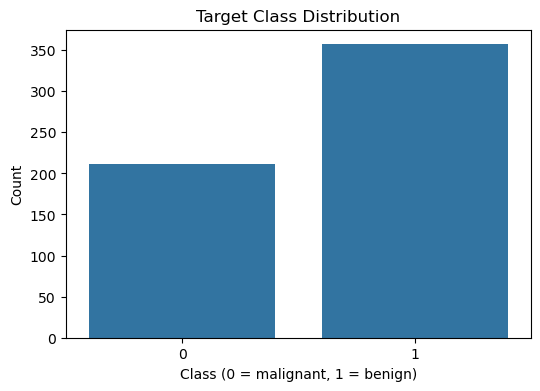

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df['target'])
plt.title("Target Class Distribution")
plt.xlabel("Class (0 = malignant, 1 = benign)")
plt.ylabel("Count")
plt.show()


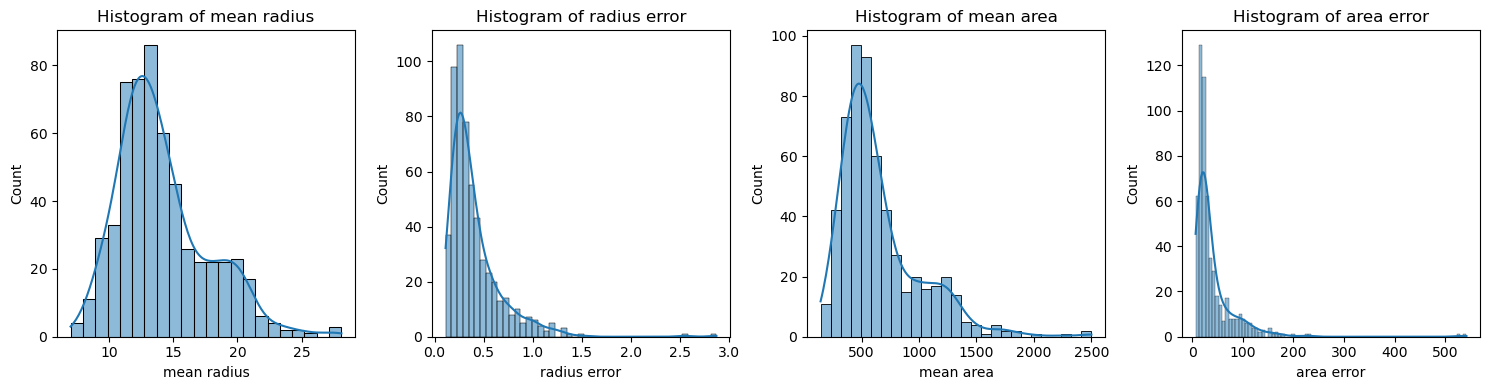

In [17]:
numeric_cols = ['mean radius', 'radius error', 'mean area', 'area error']

plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")

plt.tight_layout()
plt.show()


Classes seem to be a little unbalanced but with a right skew on the error graphs. The general numerican graphs almost have a normal distribution but sort of skew right as well.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['mean radius', 'radius error', 'mean area', 'area error']]
y = df[['target']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
print("Before SMOTE:", y_train.value_counts())

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", y_train_resampled.value_counts())


Before SMOTE: target
1         71
0         42
Name: count, dtype: int64
After SMOTE: target
0         71
1         71
Name: count, dtype: int64


In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = GaussianNB()

model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,3))

class_report = classification_report(y_test, y_pred)
print("Classification Report:", class_report)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", conf_matrix)

Accuracy: 0.882
Classification Report:               precision    recall  f1-score   support

           0       0.95      0.72      0.82       170
           1       0.86      0.98      0.91       286

    accuracy                           0.88       456
   macro avg       0.90      0.85      0.87       456
weighted avg       0.89      0.88      0.88       456

Confusion matrix:
 [[123  47]
 [  7 279]]


c:\Users\wilso\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Why might class imbalance hurt model performance?
How did SMOTE change the training data?
Do you think balancing the data was helpful in this case? Explain using your results.

Class imbalance will introduce biased sampling in the data and create uncertain predictions. SMOTE changes the training data to artificially balance it out using some weird math to keep the values within a reasonable range. I believe that balancing the data helped as in the report/confusion matrix, we resulted in a decent accuracy and a strong f1-score. I think compared to the original count of malignant vs benign (200-350), we got a fairly proportional prediction with our model as well (123-279) for the accurate predictions. 